# 01: Exploring the data

Before building any models, I want to get a feel for the data: where admission rates are high, how they relate to
remoteness and disadvantage, how much COVID moved things, and what's missing. Everything here reads the cleaned
SA3 table that `dap health build` makes, and the charts come from `src/dap/health/eda.py`, so this notebook is
mostly me looking at the results and writing down what I notice.

If you're running this yourself, run `uv run dap health fetch` and `uv run dap health build` first (see the
[main README](../../../README.md#reproduce-it-yourself)).

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
from IPython.display import display

from dap.common import paths
from dap.common.io import read_json
from dap.common.plotting import save, use_style
from dap.health import clean, eda

use_style()
pd.set_option("display.precision", 2)
FIGURES = paths.reports_dir() / "figures"

table = gpd.read_file(paths.processed_dir() / "health_sa3.gpkg", layer="sa3").set_index("sa3_code")
summary = read_json(paths.reports_dir() / "data_summary.json")
model_rows = eda.modelling_rows(table)
s = summary
print(
    f"{s['sa3_count']} SA3s, {s['sa3_with_target']} with a {s['target_year']} rate, "
    f"in {s['sa4_count']} SA4 regions"
)

336 SA3s, 327 with a 2023-24 rate, in 88 SA4 regions


## Where are the rates high?

The map uses seven quantile classes, so each colour holds roughly the same number of SA3s. The grey areas are
the ones the AIHW doesn't publish a rate for.

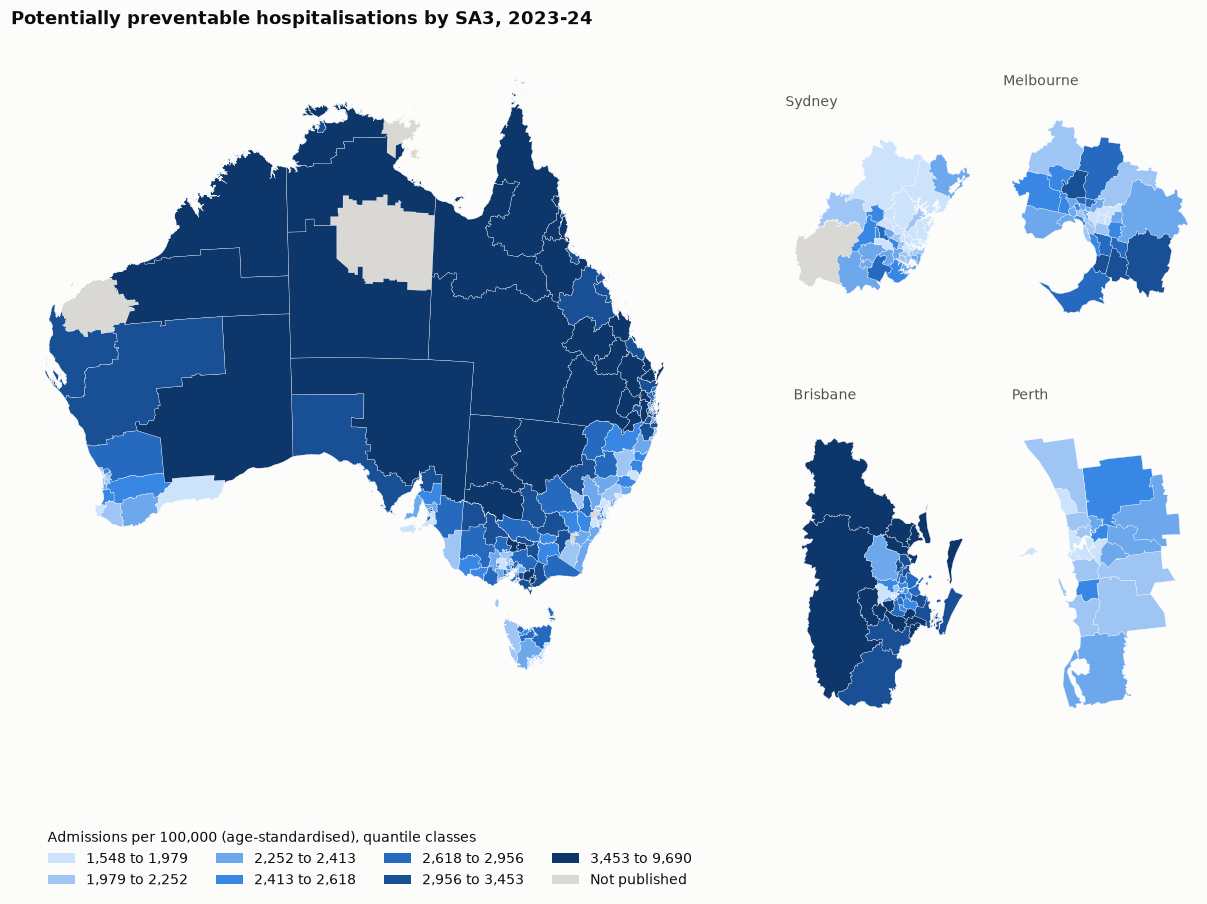

In [2]:
fig = eda.choropleth(table, title="Potentially preventable hospitalisations by SA3, 2023-24")
save(fig, FIGURES / "01_map.png");

The darkest areas are almost all remote or outer regional: the Northern Territory, northern and western
Queensland, the Kimberley and outback South Australia. In the cities the pattern is patchier. In Sydney the
lowest rates are in the north and east, while Brisbane's inset looks dark mostly because its Greater Capital City
area takes in a lot of hinterland.

The grey areas worry me a bit. A few are near-empty (catchment reserves, Lord Howe Island), but Barkly, East
Arnhem and West Pilbara are remote areas that probably have very high rates. The model will never see them.

## How much did COVID move things?

These are the AIHW's national rates, not my SA3 table.

category,pph,pph_acute,pph_chronic,pph_vaccine
year,,,,
2017-18,2794,1286,1233,313
2018-19,2735,1293,1223,245
2019-20,2557,1197,1148,238
2020-21,2371,1215,1067,101
2021-22,2308,1171,1000,155
2022-23,2503,1265,1063,197
2023-24,2617,1322,1072,252


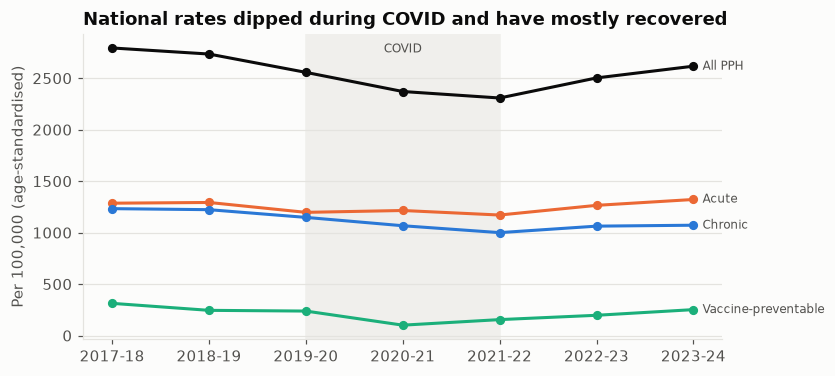

In [3]:
from dap.common.manifest import load_manifest

pph_file = load_manifest(paths.manifest_path()).get("aihw_pph_sa3").path_in(paths.raw_dir())
raw_pph = clean.read_aihw_pph(pph_file)
national = clean.national_pph(raw_pph)
display(national.pivot(index="year", columns="category", values="asr"))
save(eda.national_trend(national), FIGURES / "01_trend.png");

Vaccine-preventable admissions (mostly flu and pneumonia) fell the hardest in 2020-21, which makes sense with
lockdowns, masks and closed borders. Chronic conditions dropped too and haven't fully come back. That's why I'm
using 2023-24 as the main year.

But does COVID change *which* areas are high? If the ranking of areas stayed about the same, then the year I
pick matters less than I feared.

In [4]:
print(
    "Rank correlation between each SA3's 2018-19 and 2023-24 rates:",
    round(eda.spearman(model_rows.pph_asr, model_rows.pph_asr_2018_19), 2),
)

Rank correlation between each SA3's 2018-19 and 2023-24 rates: 0.88


Pretty stable. Areas that were high before COVID are still high now, so the year mostly shifts the level,
not the pattern.

## Remoteness and disadvantage

The AIHW sorts SA3s into six groups by remoteness, and splits the major-city ones by socioeconomic status. The
dot is the rate for the group as a whole (weighted by population), and the bar shows the range across SA3s.

,sa3s,weighted_rate,min,max
group,,,,
Major cities - higher socioeconomic areas,46,2070.19,1646.0,2874.0
Major cities - medium socioeconomic areas,90,2381.69,1648.0,3488.0
Major cities - lower socioeconomic areas,53,2781.92,1907.0,4240.0
Inner regional,79,2818.70,1548.0,6620.0
Outer regional,43,3029.05,1805.0,4773.0
Remote and very remote,16,5198.91,1896.0,9690.0


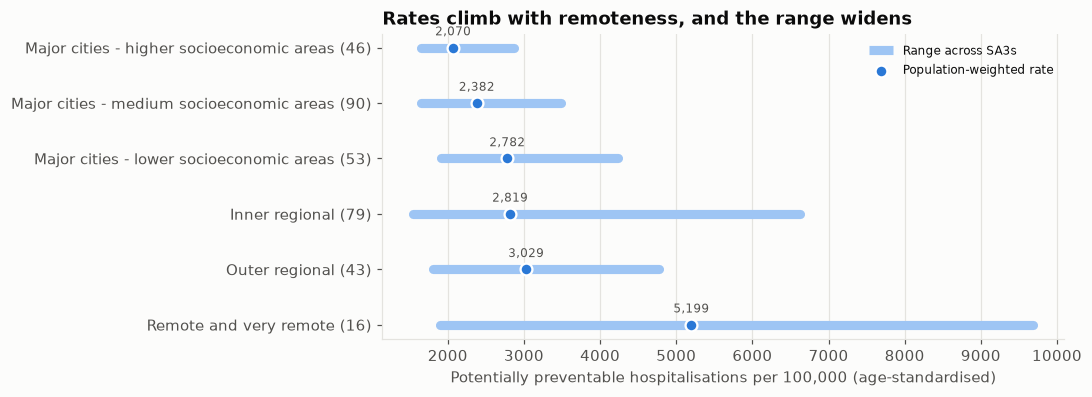

In [5]:
by_group = eda.rate_by_group(model_rows)
display(by_group)
save(eda.group_dot_chart(by_group), FIGURES / "01_groups.png");

,sa3s,weighted_rate
quintile,,
1.0,76.0,3235.38
2.0,72.0,2756.25
3.0,52.0,2566.47
4.0,63.0,2364.50
5.0,64.0,2113.49


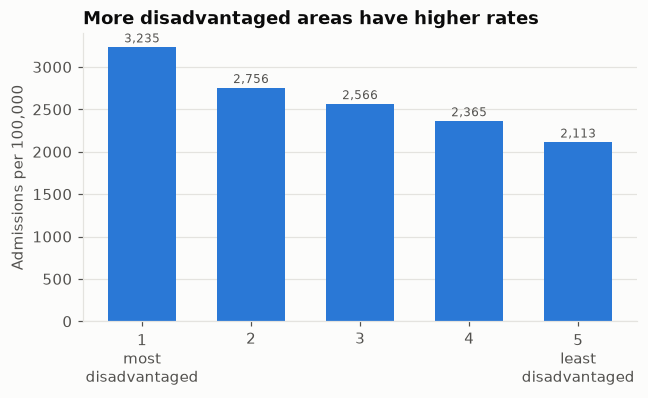

In [6]:
by_quintile = eda.rate_by_irsd_quintile(model_rows)
display(by_quintile)
save(eda.quintile_bar_chart(by_quintile), FIGURES / "01_quintiles.png");

Both patterns are clear and go the way I expected. Remote areas are in a different league, and the range
within each group grows as you move away from the cities. Inner regional has one area way out on its own
(Maryborough in Queensland, at about twice the rate of neighbouring Hervey Bay), so the group averages hide a
lot.

The quintiles are population-weighted, so each one holds about a fifth of the population, not a fifth of the
SA3s.

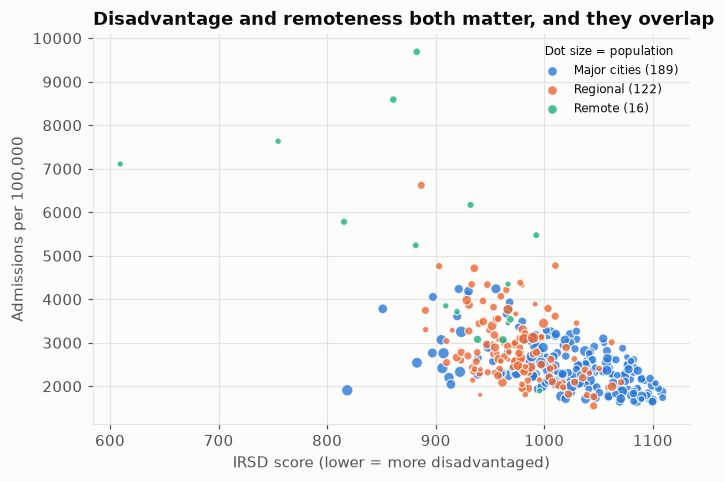

In [7]:
save(eda.scatter_irsd(model_rows), FIGURES / "01_scatter.png");

Disadvantage and remoteness overlap a lot (remote areas are also some of the most disadvantaged), which is
one reason I need a model rather than just reading these charts.

The point that caught my eye is the city dot far to the left but low down: a very disadvantaged area with a
below-average rate. Let me find it.

In [8]:
cols = ["sa3_name", "irsd_score", "pph_asr", "born_nes_pct", "poor_english_pct"]
unexpected = (model_rows.irsd_score < 900) & (model_rows.pph_asr < 3000)
model_rows[unexpected][cols].sort_values("irsd_score")

,sa3_name,irsd_score,pph_asr,born_nes_pct,poor_english_pct
sa3_code,,,,,
12702,Fairfield,818.56,1907.0,54.38,22.25
12503,Merrylands - Guildford,882.76,2540.0,43.28,11.29
11603,Mount Druitt,896.94,2765.0,35.30,4.55


It's Fairfield in Sydney's south-west: one of the most disadvantaged SA3s in the country, but with a rate
below the national median. More than half its residents were born in a non-English-speaking country. Research on
the "healthy migrant effect" suggests migrants are often healthier on arrival than the average Australian, and
there could also be differences in how people use GPs and hospitals. I can't prove any of that from area data,
but it's exactly the kind of area I expect the residual map to pick out, so I'm noting it here to check later.

## Which inputs go with higher rates?

Spearman correlation of each Tier A input with the 2023-24 rate. Red means areas with more of that thing have
more admissions.

,weakest
aged_care_places_per_1000,3.31e-02
age_65_plus_pct,-2.97e-02
gp_services_per_100,2.91e-02
immunised_5yr_pct,-2.83e-02
ra_inner_regional_share,2.77e-02
no_motor_vehicle_pct,1.28e-02
immunised_2yr_pct,-6.04e-03
breast_screening_pct,-4.16e-03


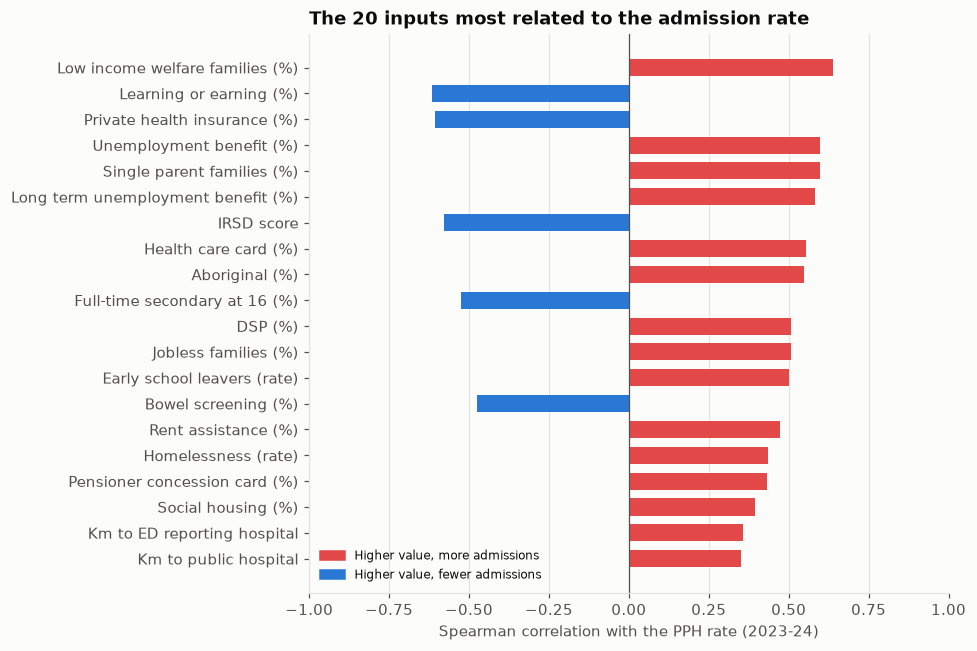

In [9]:
corr = eda.feature_correlations(model_rows)
save(eda.correlation_chart(corr), FIGURES / "01_correlations.png")
corr.tail(8).rename("weakest").to_frame()

Almost every strong relationship is some version of "this area is poorer": welfare dependence, unemployment
benefits, single-parent families, Health Care Cards, lower IRSD scores and less private insurance. Distance to a
hospital matters too, but less. Some of the prevention inputs, like childhood immunisation, barely relate to the
rate at all.

The one that surprised me most is GP visits per person, which sits near the bottom of the list. PPH is meant to be
a sign of how well primary care is working, so I expected areas that see their GP more to have fewer admissions.
On its own, the number of GP visits doesn't seem to say much. It might be that sicker areas use GPs more *and*
end up in hospital more, so the two effects cancel out. The model, which can hold other things constant, should
tell me more.

The catch is that these socioeconomic inputs mostly measure the same thing:

In [10]:
top = [
    "low_income_welfare_families_pct",
    "unemployment_benefit_pct",
    "single_parent_families_pct",
    "health_care_card_pct",
    "irsd_score",
    "private_health_insurance_pct",
]
model_rows[top].rank().corr().rename(columns=eda.label, index=eda.label)

,Low income welfare families (%),Unemployment benefit (%),Single parent families (%),Health care card (%),IRSD score,Private health insurance (%)
Low income welfare families (%),1.00,0.91,0.77,0.85,-0.91,-0.73
Unemployment benefit (%),0.91,1.00,0.85,0.93,-0.93,-0.78
Single parent families (%),0.77,0.85,1.00,0.76,-0.80,-0.68
Health care card (%),0.85,0.93,0.76,1.00,-0.89,-0.82
IRSD score,-0.91,-0.93,-0.80,-0.89,1.00,0.83
Private health insurance (%),-0.73,-0.78,-0.68,-0.82,0.83,1.00


They're highly correlated with each other. For the linear models that means I'll need regularisation
(ridge), and when I interpret any model I shouldn't read too much into which of these "wins". They're close to
interchangeable.

## What's missing

Only the SA3s that have a target are counted here.

In [11]:
eda.missingness(table)

,feature,tier,group,missing_sa3
53,high_blood_pressure_asr,B,health_status,13
52,psych_distress_asr,B,health_status,13
51,fair_poor_health_asr,B,health_status,13
56,risky_drinking_asr,B,health_status,13
55,current_smokers_asr,B,health_status,13
57,physically_inactive_asr,B,health_status,13
54,obese_asr,B,health_status,13
41,no_early_antenatal_pct,A,prevention,7
35,gp_after_hours_per_100,A,gp_use,1
33,gp_any_claim_pct,A,gp_use,1


The core (Tier A) inputs are nearly complete: one SA3 is missing GP data and a handful are missing the
antenatal figure, so simple imputation inside each training fold will do. The Tier B health estimates are
missing for 13 SA3s, mostly remote ones, so that sensitivity check will quietly drop some of the highest-rate
areas. I'll say so when I report it.

## Shape of the target

In [12]:
print(
    "skewness:",
    round(model_rows.pph_asr.skew(), 2),
    " on a log scale:",
    round(np.log(model_rows.pph_asr).skew(), 2),
)
model_rows.pph_asr.describe()

skewness: 3.0  on a log scale: 1.17


count     327.00
mean     2750.30
std       984.92
min      1548.00
25%      2167.00
50%      2524.00
75%      3067.50
max      9690.00
Name: pph_asr, dtype: float64

The rate is very right-skewed: most SA3s sit in a fairly narrow band and a few remote ones go much higher.
On a log scale it's far more even, so I'll model the log of the rate and convert back when I report errors.
Otherwise a handful of remote areas would dominate the fit.

## What this means for the modelling

- **Use 2023-24**, with 2018-19 as a check. The ranking of areas barely changed through COVID.
- **Model the log rate**, weighted by population, and report errors back on the original scale.
- **Expect the socioeconomic inputs to overlap.** Use ridge regression and be careful when interpreting.
- **Neighbouring areas look alike on the map**, so a random train/test split will probably flatter the models.
  The next notebook tests that properly (Moran's I) and uses spatial cross-validation.
- **Keep an eye on Fairfield-type areas**, the ones that do much better or worse than their profile suggests.
  That's the whole point of the project.